# Compute the Ground-state Energy of Formaldehyde using Fire Opal
**Integrate Fire Opal into a quantum chemistry workflow for ground-state energy estimation**

Computing the ground-state energy of a molecular system is a central task in electronic structure theory. From a classical perspective, high-accuracy methods such as Coupled Cluster with Singles and Doubles (CCSD) or multi-reference approaches can be used to obtain reliable reference energies, but their computational cost grows rapidly with system size and basis quality. 

Quantum computing offers a complementary route, where we map the molecular Hamiltonian to a qubit operator and use quantum circuits to approximate the ground state within the relevant fermionic Hilbert space. In this application note, we solve the ground-state problem for formaldehyde ($\text{CH}_{2}\text{O}$), a small but chemically nontrivial molecule using Sample-based quantum diagonalization (SQD) eigenstate solver executed with and without Fire Opal. This application note covers the following:

- An introduction to the $\text{CH}_{2}\text{O}$ electronic structure problem and active-space construction  
- An introduction to the SQD workflow  
- Execution of the eigenstate solver for $\text{CH}_{2}\text{O}$   
- Evaluation of the solver performance in terms of energy error 


## 1. Introduction

We will compute the correlated ground-state energy of formaldehyde ($\text{CH}_{2}\text{O}$). The problem is formulated in a standard second-quantized setting, reduced to a chemically meaningful active space, and then mapped to a qubit Hamiltonian suitable for near-term processors. The Sample-based Quantum Diagonalization (SQD) solver uses bitstrings sampled from this Hamiltonian to reconstruct an approximate ground state. By executing the same SQD workflow with and without Fire Opal, we obtain a controlled comparison of accuracy and robustness for a nontrivial, yet still classically tractable, molecular benchmark.

### 1.1 Electronic structure of formaldehyde ($\text{CH}_{2}\text{O}$)
We start with a standard quantum-chemistry pipeline. Given the formaldehyde's molecular geometry in the `3-21G` basis set, a Hartree–Fock (HF) calculation provides a set of molecular orbitals, their occupations, and a mean-field ground-state energy. We use the Jordan–Wigner transformation to map the fermionic wavefunction of formaldehyde onto a qubit wavefunction that can be prepared on a quantum circuit. The JW mapping takes a system with $M$ spatial orbitals and represents it in a Hilbert space of $2M$ qubits, each spatial orbital is split into two spin orbitals, one for spin-up $\alpha$ and one for spin-down $\beta$, each represented by a single qubit. 

For formaldehyde in the `3-21G` basis, the Hartree–Fock calculation gives 22 spatial orbitals, $22\alpha+22\beta=44$ spin orbitals. Neutral $\text{CH}_{2}\text{O}$ has 16 electrons, and with a singlet reference $\text{spin}=0$ this corresponds to $8\alpha$ and $8\beta$ electrons. In the correlated calculation, we freeze the two lowest-energy spatial orbitals, they remain doubly occupied and do not participate in the calculation. This removes $4$ core electrons, leaving $12$ active electrons ($6\alpha$ and $6\beta$) distributed among the $20$ active spatial orbitals, or $40$ spin orbitals, so the quantum circuit effectively uses $40$ qubits to encode the electronic structure. The resulting fermionic Hilbert space has dimension $\binom{20}{6}^2 \approx 1.5 \times 10^9$, which is far too large for which is far too large for exact diagonalization. 

### 1.2 Sample-based Quantum Diagonalization (SQD) workflow

To approximate the ground state of the $\text{CH}_{2}\text{O}$ Hamiltonian on a quantum device, we use the Sample-based Quantum Diagonalization (SQD) eigenstate solver, which combines a parameterized quantum circuit that explores relevant regions of Hilbert space with a classical subspace solver that reconstructs an approximate ground state from the sampled configurations. By working in a data-driven subspace determined directly from measurements on the device, SQD avoids the need to manipulate the full $2^N$-dimensional state vector while still capturing the dominant components of the ground state. The iterative nature of the method naturally provides diagnostics, such as orbital occupancy patterns, that can be used to assess whether the reconstructed state remains physically meaningful.

## 2. Imports and initializations

The following section sets up the necessary imports, credentials, and helper functions.

> pip install qiskit_addon_sqd qctrlvisualizer pyscf

In [ ]:
from qiskit import QuantumCircuit, qasm3
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_addon_sqd.configuration_recovery import recover_configurations
from qiskit_addon_sqd.fermion import bitstring_matrix_to_ci_strs, solve_fermion
from qiskit_addon_sqd.subsampling import postselect_by_hamming_right_and_left, subsample
from qiskit_addon_sqd.counts import counts_to_arrays

import ffsim
from pyscf import cc
from pyscf.geomopt.geometric_solver import optimize
from pyscf import ao2mo, gto, mcscf, scf

import numpy as np
import fireopal as fo
import qctrlvisualizer as qv
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

### 2.1 Credentials and backend

We have developed this notebook to run on an IBM backend. To run it, you need an [IBM Quantum account](https://quantum.cloud.ibm.com/). Set up Fire Opal with your IBM account information and choose a backend.

In [ ]:
token = "YOUR_IBM_CLOUD_API_KEY"
instance = "YOUR_IBM_CRN"

credentials = fo.credentials.make_credentials_for_ibm_cloud(
    token=token, instance=instance
)

Q-CTRL authentication successful!


In [ ]:
# Enter your desired IBM backend here.
service = QiskitRuntimeService()
backend = service.backend("your_desired_backend")

## 3. Molecular geometry and Hartree–Fock reference

We start by defining the formaldehyde molecule in a minimal but chemically meaningful setup. The `Mole` object specifies the nuclear geometry, the electronic structure model, and basic quantum numbers. The atomic positions correspond to a standard equilibrium geometry for $\text{CH}_{2}\text{O}$, with the oxygen and carbon placed along the $x$ axis and the two hydrogens arranged asymmetrically around the carbon, capturing the planar structure of the molecule. The total charge is set to zero and the spin multiplicity corresponds to a singlet state `spin = 0`, so the calculation describes neutral formaldehyde in its electronic ground state. A restricted Hartree–Fock (RHF) calculation is performed via `scf.RHF(mol).run()`. This provides the mean-field reference energy and the molecular orbital coefficients that are used in subsequent steps to construct the active-space Hamiltonian and its qubit representation.


In [ ]:
# Formaldehyde
mol = gto.Mole()
mol.build(
    verbose=0,
    atom=[
        ["O", (0.6123, 0.0000, 0.0000)],
        ["C", (-0.6123, 0.0000, 0.0000)],
        ["H", (-1.2000, 0.2426, -0.8998)],
        ["H", (-1.2000, -0.2424, 0.8998)],
    ],
    basis="3-21G",
    spin=0,
    charge=0,
    symmetry=False,
)

mf = scf.RHF(mol).run()

The optimize routine takes the mean-field object mf as input and performs a geometry optimization using translation–rotation internal coordinates (TRIC). The resulting object contains the optimized nuclear positions used as the starting point for constructing the correlated Hamiltonian in the chosen active space.

In [ ]:
mol_opt = optimize(mf, tol_grad=3e-4, verbose=0)  # Use geomeTRIC/TRIC under the hood

geometric-optimize called with the following command line:
/home/nemo/miniconda3/envs/q-chemistry/lib/python3.11/site-packages/ipykernel_launcher.py --f=/run/user/1000/jupyter/runtime/kernel-v3bb13e301defbc9bd1453787936876a3100b92123.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%%%%%%,  

Current date and time: 2025-11-27 22:44:01
#========================================================#
#|     Arguments passed to driver run_optimizer():      |#
#========================================================#
customengine              <pyscf.geomopt.geometric_solver.PySCFEngine object at 0x7cf65895f890> 
input                     /tmp/tmp2abw76ya/09ad8e40-f9ba-43da-99ef-02144fb147e9 
logIni                    /home/nemo/miniconda3/envs/q-chemistry/lib/python3.11/site-packages/pyscf/geomopt/log.ini 
maxiter                   100 
tol_grad                  0.0003 
verbose                   0 
----------------------------------------------------------
Custom engine selected.
Bonds will be generated from interatomic distances less than 1.20 times sum of covalent radii
12 internal coordinates being used (instead of 12 Cartesians)
Internal coordinate system (atoms numbered from 1):
Distance 1-2
Distance 2-3
Distance 2-4
Angle 1-2-4
Angle 3-2-4
Out-of-Plane 2-1-3-4
Translation-X 1-

With the optimized geometry we recompute the restricted Hartree–Fock energy. To obtain a high-quality classical reference for the correlated ground-state energy, we perform a CCSD calculation on the optimized Hartree–Fock reference, using a frozen-core approximation consistent with the active-space setup:

In [ ]:
# Run the kernel to get the RHF energy
mf_opt = scf.RHF(mol_opt)
hf_e = float(mf_opt.kernel())
print(f"Restricted Hartree-Fock Energy: {hf_e}")

Restricted Hartree-Fock Energy: -113.22181990503708


In [ ]:
ccsd = cc.CCSD(mf_opt).set(frozen=2).run()
exact_energy = ccsd.e_tot
print("CCSD reference energy:", exact_energy)

CCSD reference energy: -113.44730072803931


### 3.1 Active-space Hamiltonian and reference amplitudes

With the active-space definition, we construct the corresponding many-body Hamiltonian and extract the integrals needed for the SQD solver.


In [ ]:
open_shell = False
spin_sq = 0
n_frozen = 2
active_space = range(n_frozen, mol_opt.nao_nr())
num_orbitals = len(active_space)
n_electrons = int(sum(mf_opt.mo_occ[active_space]))
num_elec_a = (n_electrons + mol_opt.spin) // 2
num_elec_b = (n_electrons - mol_opt.spin) // 2
cas = mcscf.CASCI(mf_opt, num_orbitals, (num_elec_a, num_elec_b))
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = ao2mo.restore(1, cas.get_h2cas(mo), num_orbitals)
t1 = ccsd.t1
t2 = ccsd.t2

To generate a trial state for the SQD workflow, we use a unitary cluster Jastrow (UCJ) ansatz constructed from the CCSD single and double excitation amplitudes. The `ffsim` library provides a convenient interface for this through the `UCJOpSpinBalanced` operator, which builds a spin-balanced UCJ circuit tailored to the active-space Hamiltonian.

In [ ]:
n_reps = 1
alpha_alpha_indices = [(p, p + 1) for p in range(num_orbitals - 1)]
alpha_beta_indices = [(p, p + 1) for p in range(num_orbitals - 1)]

ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
)
nelec = (num_elec_a, num_elec_b)

## 4. Circuit preparation

With the active-space Hamiltonian and the UCJ operator defined, we build the quantum circuit that prepares the trial state used for sampling in the SQD workflow. The circuit acts on a register of $2\,\text{num\_orbitals}$ qubits, corresponding to the $\alpha$ and $\beta$ spin orbitals in the active space, and is initialized in the Hartree–Fock configuration before the UCJ transformation is applied.


In [ ]:
qubits = QuantumRegister(2 * num_orbitals, name="q")
circuit = QuantumCircuit(qubits)
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, nelec), qubits)
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
circuit.measure_all()

In [ ]:
pass_manager = generate_preset_pass_manager(optimization_level=3, backend=backend)
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/o pre-init passes): {isa_circuit.count_ops()}")
pass_manager.pre_init = ffsim.qiskit.PRE_INIT
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/ pre-init passes): {isa_circuit.count_ops()}")

Pass: ContainsInstruction - 0.02122 (ms)Pass: UnitarySynthesis - 0.02456 (ms)Pass: HighLevelSynthesis - 101.91250 (ms)Pass: BasisTranslator - 0.17643 (ms)Pass: ElidePermutations - 0.01192 (ms)Pass: RemoveDiagonalGatesBeforeMeasure - 0.03171 (ms)Pass: RemoveIdentityEquivalent - 0.17881 (ms)Pass: InverseCancellation - 0.15092 (ms)Pass: ContractIdleWiresInControlFlow - 0.00715 (ms)Pass: CommutativeCancellation - 0.96846 (ms)Pass: ConsolidateBlocks - 8.52537 (ms)Pass: Split2QUnitaries - 0.01407 (ms)Pass: SetLayout - 0.00668 (ms)Pass: VF2Layout - 1.28508 (ms)Pass: BarrierBeforeFinalMeasurements - 0.51451 (ms)Pass: SabreLayout - 487.84590 (ms)Pass: CheckMap - 0.17428 (ms)Pass: VF2PostLayout - 1086.56836 (ms)Pass: ApplyLayout - 0.75722 (ms)Pass: FilterOpNodes - 0.62156 (ms)Pass: UnitarySynthesis - 0.01669 (ms)Pass: HighLevelSynthesis - 0.23365 (ms)Pass: BasisTranslator - 23.53239 (ms)Pass: Depth - 6.21009 (ms)Pass: Size - 0.01383 (ms)Pass: MinimumPoint - 0.01907 (ms)Pass: ConsolidateBlocks - 

Gate counts (w/o pre-init passes): OrderedDict([('sx', 8254), ('rz', 6923), ('cz', 3042), ('x', 500), ('measure', 40), ('barrier', 1)])


Pass: SabreLayout - 510.85472 (ms)Pass: CheckMap - 0.19765 (ms)Pass: VF2PostLayout - 175.64106 (ms)Pass: ApplyLayout - 0.82803 (ms)Pass: FilterOpNodes - 0.36907 (ms)Pass: UnitarySynthesis - 0.01335 (ms)Pass: HighLevelSynthesis - 0.15497 (ms)Pass: BasisTranslator - 8.40044 (ms)Pass: Depth - 2.19154 (ms)Pass: Size - 0.01073 (ms)Pass: MinimumPoint - 0.02050 (ms)Pass: ConsolidateBlocks - 15.45191 (ms)Pass: UnitarySynthesis - 26.01624 (ms)Pass: RemoveIdentityEquivalent - 0.71621 (ms)Pass: Optimize1qGatesDecomposition - 6.10590 (ms)Pass: CommutativeCancellation - 5.45287 (ms)Pass: ContractIdleWiresInControlFlow - 0.00978 (ms)Pass: GatesInBasis - 1.36399 (ms)Pass: Depth - 1.27196 (ms)Pass: Size - 0.00930 (ms)Pass: MinimumPoint - 1.31655 (ms)Pass: ConsolidateBlocks - 9.19533 (ms)Pass: UnitarySynthesis - 3.64876 (ms)Pass: RemoveIdentityEquivalent - 0.43750 (ms)Pass: Optimize1qGatesDecomposition - 3.54743 (ms)Pass: CommutativeCancellation - 5.38278 (ms)Pass: ContractIdleWiresInControlFlow - 0.00

Gate counts (w/ pre-init passes): OrderedDict([('sx', 4555), ('rz', 3791), ('cz', 1646), ('x', 142), ('measure', 40), ('barrier', 1)])


In [ ]:
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=10_000)

base_primitive._run:INFO:2025-11-27 22:47:29,267: Submitting job using options {'options': {}, 'version': 2, 'support_qiskit': True}


### 5. Running the algorithm  
Run the $\text{CH}_{2}\text{O}$ UCJ trial circuit, with and without Fire Opal, to collect the measurement samples required for the SQD ground-state reconstruction.

In [ ]:
# Run cell after IQX job completion
primitive_result = job.result()
pub_result = primitive_result[0]
counts_default = pub_result.data.meas.get_counts()

In [ ]:
fire_opal_job = fo.execute(
    circuits=[qasm3.dumps(circuit.decompose(reps=5))],
    shot_count=10_000,
    credentials=credentials,
    backend_name=backend.name,
)

In [ ]:
counts_fo = fire_opal_job.result()["results"][0]

## 6. SQD analysis and performance evaluation

The measurement data are now used as input to the SQD workflow. The function `calculate_energies` implements the full configuration-recovery and eigenstate-reconstruction loop: it converts the raw counts into bitstring and probability arrays, iteratively refines the configuration set using average orbital occupancies, and solves a sequence of reduced eigenvalue problems in the active-space sector.

In [ ]:
rng = np.random.default_rng(24)
iterations = 3
samples_schedule = [600, 800, 1000, 1200, 1400]
experiments = len(samples_schedule)
n_batches = 5
max_davidson_cycles = 300

In [ ]:
def calculate_energies(counts):
    bitstring_matrix_full, probs_arr_full = counts_to_arrays(counts)
    e_hist = np.zeros((experiments, iterations, n_batches))
    s_hist = np.zeros((experiments, iterations, n_batches))
    occupancy_hist = [[None for _ in range(iterations)] for _ in range(experiments)]

    for ex, spb in enumerate(samples_schedule):
        print(f"\n=== Experiment {ex} – samples_per_batch = {spb} ===")
        avg_occupancy = None
        for i in range(iterations):
            print(f"  Starting configuration recovery iteration {i}")
            if avg_occupancy is None:
                bs_mat_tmp = bitstring_matrix_full
                probs_arr_tmp = probs_arr_full
            else:
                bs_mat_tmp, probs_arr_tmp = recover_configurations(
                    bitstring_matrix_full,
                    probs_arr_full,
                    avg_occupancy,
                    num_elec_a,
                    num_elec_b,
                    rand_seed=rng,
                )
            postselected_bs_mat, postselected_probs_arr = (
                postselect_by_hamming_right_and_left(
                    bs_mat_tmp,
                    probs_arr_tmp,
                    hamming_right=num_elec_a,
                    hamming_left=num_elec_b,
                )
            )
            batches = subsample(
                postselected_bs_mat,
                postselected_probs_arr,
                samples_per_batch=spb,
                num_batches=n_batches,
                rand_seed=rng,
            )
            e_tmp = np.zeros(n_batches)
            s_tmp = np.zeros(n_batches)
            occs_tmp = []
            coeffs = []
            for j in range(n_batches):
                strs_a, strs_b = bitstring_matrix_to_ci_strs(batches[j])
                print(f"    Batch {j} subspace dimension: {len(strs_a) * len(strs_b)}")
                energy_sci, coeffs_sci, avg_occs, spin = solve_fermion(
                    batches[j],
                    hcore,
                    eri,
                    open_shell=open_shell,
                    spin_sq=spin_sq,
                    max_cycle=max_davidson_cycles,
                )
                energy_sci += nuclear_repulsion_energy
                e_tmp[j] = energy_sci
                print(f"    Energy {j}: {energy_sci}")
                s_tmp[j] = spin
                occs_tmp.append(avg_occs)
                coeffs.append(coeffs_sci)
            avg_occupancy = tuple(np.mean(occs_tmp, axis=0))
            e_hist[ex, i, :] = e_tmp
            s_hist[ex, i, :] = s_tmp
            occupancy_hist[ex][i] = avg_occupancy
    min_e = [np.min(e_hist[ex, -1, :]) for ex in range(experiments)]
    e_diff = [abs(e - exact_energy) for e in min_e]
    x1 = samples_schedule
    yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
    chem_accuracy = 0.001
    last_occ = occupancy_hist[-1][-1]
    y2 = last_occ[0] + last_occ[1]
    x2 = range(len(y2))
    return e_hist, min_e, e_diff, yt1, chem_accuracy, x1, y2, x2

In [ ]:
# Convert counts into bitstring and probability arrays
e_hist_fo, min_e_fo, e_diff_fo, yt1_fo, chem_accuracy_fo, x1_fo, y2_fo, x2_fo = (
    calculate_energies(counts_fo)
)


=== Experiment 0 – samples_per_batch = 600 ===
  Starting configuration recovery iteration 0
    Batch 0 subspace dimension: 26896
    Energy 0: -113.2875885778956
    Batch 1 subspace dimension: 26896
    Energy 1: -113.2875885778956
    Batch 2 subspace dimension: 26896
    Energy 2: -113.2875885778956
    Batch 3 subspace dimension: 26896
    Energy 3: -113.2875885778956
    Batch 4 subspace dimension: 26896
    Energy 4: -113.2875885778956
  Starting configuration recovery iteration 1
    Batch 0 subspace dimension: 944784
    Energy 0: -113.38930801929412
    Batch 1 subspace dimension: 887364
    Energy 1: -113.38744860524812
    Batch 2 subspace dimension: 960400
    Energy 2: -113.35849912053587
    Batch 3 subspace dimension: 944784
    Energy 3: -113.39705880577881
    Batch 4 subspace dimension: 917764
    Energy 4: -113.39633464939948
  Starting configuration recovery iteration 2
    Batch 0 subspace dimension: 938961
    Energy 0: -113.37303988498914
    Batch 1 subspace 

In [ ]:
(
    e_hist_default,
    min_e_default,
    e_diff_default,
    yt1_default,
    chem_accuracy_default,
    x1_default,
    y2_default,
    x2_default,
) = calculate_energies(counts_default)


=== Experiment 0 – samples_per_batch = 600 ===
  Starting configuration recovery iteration 0
    Batch 0 subspace dimension: 9604
    Energy 0: -108.7451340647797
    Batch 1 subspace dimension: 9604
    Energy 1: -108.7451340647797
    Batch 2 subspace dimension: 9604
    Energy 2: -108.7451340647797
    Batch 3 subspace dimension: 9604
    Energy 3: -108.7451340647797
    Batch 4 subspace dimension: 9604
    Energy 4: -108.7451340647797
  Starting configuration recovery iteration 1
    Batch 0 subspace dimension: 1292769
    Energy 0: -111.94008269184971
    Batch 1 subspace dimension: 1283689
    Energy 1: -111.90964108773579
    Batch 2 subspace dimension: 1285956
    Energy 2: -111.61918103587362
    Batch 3 subspace dimension: 1301881
    Energy 3: -112.11324484954643
    Batch 4 subspace dimension: 1301881
    Energy 4: -111.60948309409991
  Starting configuration recovery iteration 2
    Batch 0 subspace dimension: 1140624
    Energy 0: -113.26509549780968
    Batch 1 subspace

To assess sample efficiency, we compare the final SQD ground-state energy error as a function of the total number of measurement samples, with and without Fire Opal. For each point in the sampling schedule, the bar chart reports the absolute deviation from the CCSD reference energy (lower values indicate better performance) as a function of the maximum subspace dimension, following three rounds of classical configuration recovery. The subspace dimension indicates the classical computational resources allocated during the diagonalization step, larger dimensions require more classical computation but allow the solver to explore a richer basis of sampled configurations. Both execution methods are evaluated on the same backend with identical shot budgets to ensure a fair comparison.

The results reveal two principal trends. First, increasing the subspace dimension improves accuracy for both methods, since the classical solver gains access to a larger configuration space. Second, Fire Opal consistently achieves substantially lower error, approximately four times better across all tested subspace dimensions. This consistent improvement indicates that the use of Fire Opal enables the SQD solver to reconstruct a more accurate ground state from the same number of measurements.


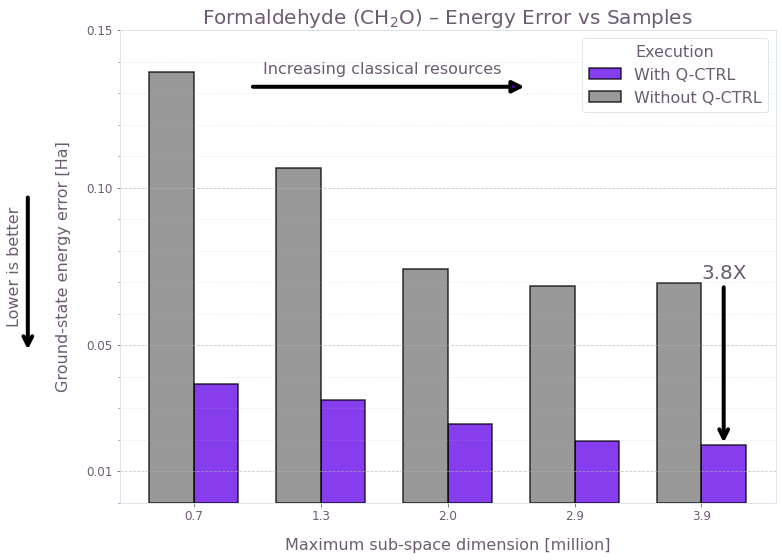

In [ ]:
plt.style.use(qv.get_qctrl_style())
samples = np.array(samples_schedule)
default_err = np.array(e_diff_default)
fo_err = np.array(e_diff_fo)
x = np.arange(len(samples))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 8))

ax.bar(
    x + width / 2,
    fo_err,
    width,
    label="With Q-CTRL",
    alpha=0.8,
    edgecolor="black",
    linewidth=1.5,
)
ax.bar(
    x - width / 2,
    default_err,
    width,
    label="Without Q-CTRL",
    alpha=0.8,
    edgecolor="black",
    linewidth=1.5,
    color="gray",
)

max_subspace_dim = 2 * (samples**2)
max_subspace_dim_millions = max_subspace_dim / 1e6
x_labels = [f"{val:.1f}" for val in max_subspace_dim_millions]
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Maximum sub-space dimension [million]", fontsize=16)
ax.set_ylabel("Ground-state energy error [Ha]", fontsize=16)
ax.set_yticks([1e-2, 5e-2, 1e-1, 1.5e-1])
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.01))
ax.grid(True, which="major", axis="y", linestyle="--", linewidth=0.8, alpha=0.7)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.8, alpha=0.4)
ax.set_title(r"Formaldehyde (CH$_2$O) – Energy Error vs Samples", fontsize=20)
ax.legend(
    title="Execution",
    labels=["With Q-CTRL", "Without Q-CTRL"],
    fontsize=16,
    title_fontsize=16,
)
ax.annotate(
    "",
    xy=(0.62, 0.88),
    xytext=(0.20, 0.88),
    xycoords="axes fraction",
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="-|>", mutation_scale=24, linewidth=4),
)
ax.text(
    0.4,
    0.9,
    "Increasing classical resources",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=16,
)
ax.annotate(
    "",
    xy=(-0.14, 0.32),
    xytext=(-0.14, 0.65),
    xycoords="axes fraction",
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", mutation_scale=22, linewidth=4),
)
ax.text(
    -0.16,
    0.5,
    "Lower is better",
    transform=ax.transAxes,
    ha="center",
    va="center",
    rotation=90,
    fontsize=16,
)
with np.errstate(divide="ignore", invalid="ignore"):
    factors = np.where(fo_err > 0, default_err / fo_err, np.nan)
best_idx = np.nanargmax(factors)
best_factor = factors[best_idx]
x_best = x[best_idx] + width / 2
y_best = fo_err[best_idx]
y_default = default_err[best_idx]
ax.annotate(
    f"{best_factor:.1f}X",
    xy=(x_best, y_best),
    xytext=(x_best, y_default),
    ha="center",
    va="bottom",
    fontsize=20,
    arrowprops=dict(arrowstyle="->", mutation_scale=22, linewidth=4),
)
plt.tight_layout()
plt.show()

The following package versions were used to produce this notebook.

In [4]:
fo.print_package_versions()

| Package               | Version |
| --------------------- | ------- |
| Python                | 3.11.14 |
| matplotlib            | 3.10.8  |
| networkx              | 3.5     |
| numpy                 | 2.3.4   |
| qiskit                | 2.2.3   |
| qiskit-ibm-runtime    | 0.43.1  |
| sympy                 | 1.14.0  |
| fire-opal             | 9.1.0   |
| qctrl-visualizer      | 9.0.0   |
| qctrl-workflow-client | 7.3.0   |
